In [11]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans

In [12]:
df = pd.read_csv('social_media_data.csv')
print(df)

                                       text    user location        date  likes  comments  shares   brand
0    Nike shoes are amazing! #Nike #Running   user1   Mumbai  2024-01-01    120        30      15    Nike
1    Adidas new collection is great #Adidas   user2    Delhi  2024-01-02     85        20      10  Adidas
2        I love my Nike trainers best ever!   user3   Mumbai  2024-01-03    200        50      25    Nike
3           Adidas vs Nike which is better?   user4     Pune  2024-01-04     60        10       5  Adidas
4   Nike Air Max release today #Nike #Shoes   user5    Delhi  2024-01-05    175        45      20    Nike
5      Worst experience with Adidas support   user6   Mumbai  2024-01-06     30         5       2  Adidas
6        Running with Nike feels incredible   user7  Chennai  2024-01-07    140        35      18    Nike
7  Adidas ultraboost very comfortable shoes   user8     Pune  2024-01-08     90        25      12  Adidas
8         Nike just released new gear #Nike   

In [13]:
df['engagement'] = df['likes'] + df['shares'] + df['comments']
print(df['engagement'])

0    165
1    115
2    275
3     75
4    240
5     37
6    193
7    127
8    222
9    152
Name: engagement, dtype: int64


In [17]:
features = df[['likes','comments','shares','engagement']]

In [18]:
kmeans = KMeans(n_clusters=3)
clusters = kmeans.fit_predict(features)

In [20]:
df['cluster'] = clusters


summary = df.groupby('cluster')[['likes','comments','shares','engagement']].mena


0    2
1    2
2    1
3    0
4    1
5    0
6    1
7    2
8    1
9    2
Name: cluster, dtype: int32


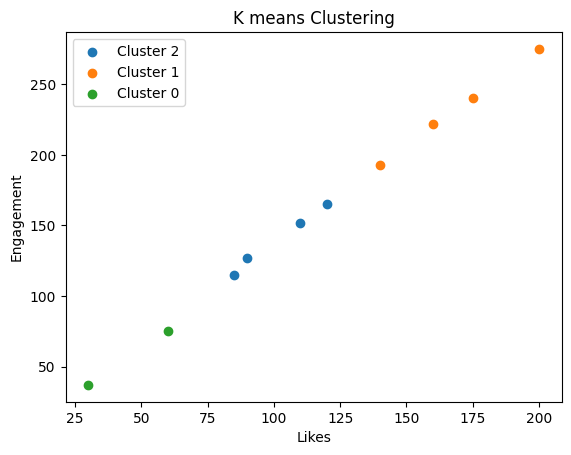

In [22]:
for c in df['cluster'].unique():
    temp = df[df['cluster'] == c]
    plt.scatter(temp['likes'], temp['engagement'] , label='Cluster ' + str(c))
plt.xlabel('Likes')
plt.ylabel('Engagement')
plt.title('K means Clustering')
plt.legend()
plt.show()